# Conexion y extraccion de datos de sismos
Objetivo: preparar los pasos iniciales del plan conectando con MongoDB y cargando los eventos en un DataFrame.

In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from pymongo import MongoClient
from dotenv import load_dotenv

In [3]:
load_dotenv()
entorno_mongo = os.getenv("MONGO_URL")

def conectar_base_mongodb():
    """Crea el cliente MongoDB usando la URL del entorno generado por IA."""
    if not entorno_mongo:
        raise ValueError("Falta la variable MONGO_URL en el entorno")
    cliente = MongoClient(entorno_mongo)
    return cliente
    # generado por IA

def cargar_data_frame(cliente):
    """Extrae la coleccion sismos y la devuelve como DataFrame generado por IA."""
    base_datos = cliente["sismosdb"]
    coleccion = base_datos["sismos"]
    registros = list(coleccion.find())
    if not registros:
        return pd.DataFrame()
    marco = pd.DataFrame(registros)
    return marco
    # generado por IA


In [4]:
def serializar_valor(valor):
    """Convierte listas/dict en tipos hashables generado por IA."""
    if isinstance(valor, dict):
        return tuple(sorted((clave, serializar_valor(dato)) for clave, dato in valor.items()))
    if isinstance(valor, (list, tuple)):
        return tuple(serializar_valor(elemento) for elemento in valor)
    return valor
    # generado por IA

def limpiar_dataframe(sismos_frame):
    """Elimina duplicados y nulos criticos del marco generado por IA."""
    if sismos_frame.empty:
        return sismos_frame
    frame = sismos_frame.copy()
    cols_con_containers = [col for col in frame.columns if frame[col].apply(lambda val: isinstance(val, (list, tuple, dict))).any()]
    for col in cols_con_containers:
        frame[col] = frame[col].map(serializar_valor)
    frame = frame.drop_duplicates()
    required_columns = [col for col in ("magnitud", "lugar", "profundidadKm") if col in frame.columns]
    if required_columns:
        frame = frame.dropna(subset=required_columns)
    # Extraccion robusta de latitud y longitud desde el campo ubicacion
    if "ubicacion" in frame.columns:
        def extraer_latitud(ubicacion):
            try:
                for item in ubicacion:
                    if item[0] == "coordinates":
                        return item[1][0]
            except Exception:
                return None
        def extraer_longitud(ubicacion):
            try:
                for item in ubicacion:
                    if item[0] == "coordinates":
                        return item[1][1]
            except Exception:
                return None
        frame["latitud"] = frame["ubicacion"].apply(extraer_latitud)
        frame["longitud"] = frame["ubicacion"].apply(extraer_longitud)
        frame = frame.dropna(subset=["latitud", "longitud"])
    if "fechaHora" in frame.columns:
        frame["fechaHora"] = pd.to_datetime(frame["fechaHora"], errors="coerce")
        frame = frame.dropna(subset=["fechaHora"])
    return frame
    # generado por IA


In [5]:
cliente = conectar_base_mongodb()
df_sismos = cargar_data_frame(cliente)
df_limpio = limpiar_dataframe(df_sismos)
df_limpio.head()

,_id,codigo,magnitud,tipoMagnitud,lugar,profundidadKm,tsunami,red,sentidos,estado,fechaHora,fuentes,estaciones,ubicacion,alerta,latitud,longitud
0,6a31264ab63f9e684795dfe5,ak600000001,5.6,mw,"Tokyo, Japan",17.6,False,ak,3112,automatic,2026-03-16 15:13:00,"(uu, hv)","(((codigo, II.KIV), (distanciaKm, 221), (magni...","((coordinates, (37.341371, 55.283089)), (type,...",NaN,37.341371,55.283089
1,6a31264ab63f9e684795dfe7,ak600000003,2.6,mwr,"Mexico City, Mexico",147.8,False,nc,3271,reviewed,2026-08-18 03:23:00,"(us,)","(((codigo, HV.HILO), (distanciaKm, 207), (magn...","((coordinates, (3.429466, -73.636306)), (type,...",green,3.429466,-73.636306
2,6a31264ab63f9e684795dfe8,ak600000004,0.9,mwr,"Tokyo, Japan",76.8,False,uu,2444,automatic,2026-11-04 09:46:00,"(hv,)","(((codigo, II.KIV), (distanciaKm, 202), (magni...","((coordinates, (94.503888, 7.088225)), (type, ...",NaN,94.503888,7.088225
3,6a31264ab63f9e684795dfe9,ak600000005,6.7,ml,"Wellington, New Zealand",371.3,True,uu,566,automatic,2026-01-15 04:22:00,"(pr,)","(((codigo, IU.COLA), (distanciaKm, 162), (magn...","((coordinates, (-8.898344, 8.964647)), (type, ...",NaN,-8.898344,8.964647
4,6a31264ab63f9e684795dfea,ak600000006,2.6,mb,"Jakarta, Indonesia",610.7,False,pr,3976,automatic,2026-05-27 11:22:00,"(us, pr, nc)","(((codigo, IU.ANMO), (distanciaKm, 209), (magn...","((coordinates, (27.436194, -46.260496)), (type...",NaN,27.436194,-46.260496


## Top sismos por magnitud
Visualizacion de los eventos sismicos de mayor magnitud.

C:\Users\UsuarioM.XTALENTO120\AppData\Local\Temp\ipykernel_24852\2969238355.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_sismos, y='lugar', x='magnitud', orient='h', palette='Reds_r')


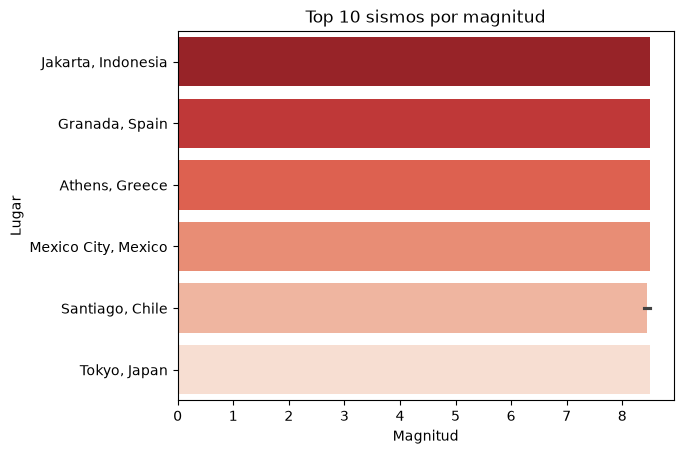

In [6]:
import matplotlib.pyplot as plt
def obtener_top_sismos(df, n=10):
    """Devuelve top n sismos por magnitud generado por IA."""
    return df.nlargest(n, 'magnitud')[['magnitud','lugar','fechaHora']]
    # generado por IA

top_sismos = obtener_top_sismos(df_limpio, 10)
sns.barplot(data=top_sismos, y='lugar', x='magnitud', orient='h', palette='Reds_r')
plt.title('Top 10 sismos por magnitud')
plt.xlabel('Magnitud')
plt.ylabel('Lugar')
plt.show()

## Frecuencia de sismos por ciudad/pais
Ranking total y evolucion temporal para los lugares mas afectados.

C:\Users\UsuarioM.XTALENTO120\AppData\Local\Temp\ipykernel_24852\142395707.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.loc[top_lugares], y=top_lugares, orient='h', palette='Blues')


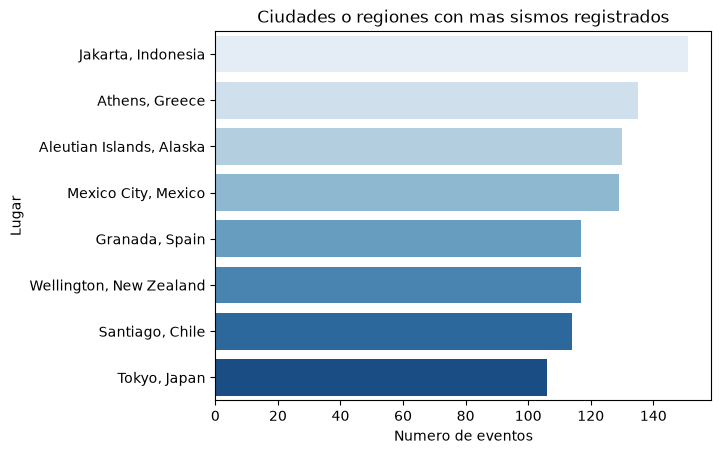

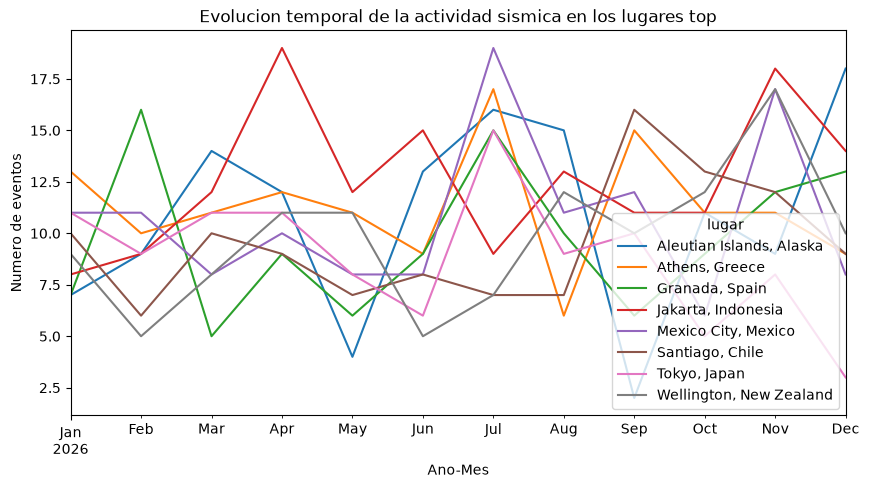

In [7]:
import matplotlib.pyplot as plt
def conteo_por_lugar(df, col='lugar'):
    """Cuenta eventos por lugar generado por IA."""
    return df.groupby(col).size().sort_values(ascending=False)
    # generado por IA
conteo = conteo_por_lugar(df_limpio)
top_lugares = conteo.head(10).index
sns.barplot(x=conteo.loc[top_lugares], y=top_lugares, orient='h', palette='Blues')
plt.title('Ciudades o regiones con mas sismos registrados')
plt.xlabel('Numero de eventos')
plt.ylabel('Lugar')
plt.show()
def evolucion_sismos(df, lugares):
    """Devuelve tabla temporal de frecuencia de sismos por lugar generado por IA."""
    df = df[df['lugar'].isin(lugares)].copy()
    df['ano_mes'] = df['fechaHora'].dt.to_period('M')
    return df.groupby(['lugar','ano_mes']).size().unstack(0).fillna(0)
    # generado por IA
tabla = evolucion_sismos(df_limpio, top_lugares)
tabla.plot(figsize=(10,5))
plt.title('Evolucion temporal de la actividad sismica en los lugares top')
plt.xlabel('Ano-Mes')
plt.ylabel('Numero de eventos')
plt.show()

## Mapa de ubicacion geografica de sismos
Distribucion de eventos segun latitud y longitud, coloreando por magnitud.

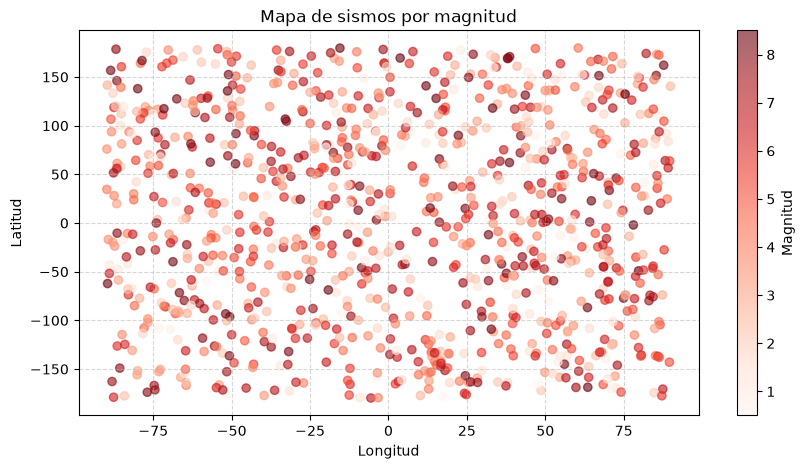

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
scatter = plt.scatter(df_limpio['longitud'], df_limpio['latitud'], c=df_limpio['magnitud'], cmap='Reds', alpha=0.6)
plt.colorbar(scatter, label='Magnitud')
plt.title('Mapa de sismos por magnitud')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Mapa mundial de sismos (Cartopy)
Visualizacion scatterplot sobre mapa, coloreando por magnitud.

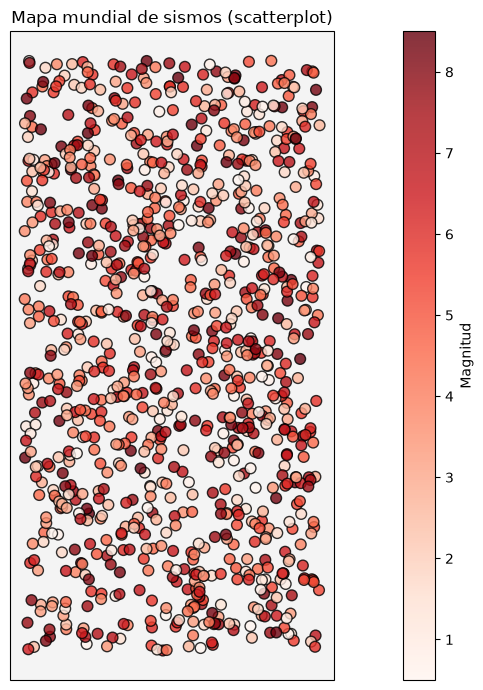

In [22]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.AlbersEqualArea())
ax.coastlines(resolution='110m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='#F2F2F2', alpha=0.8)
ax.add_feature(cfeature.OCEAN, facecolor='#e0e7fa', alpha=0.8)
scatter = plt.scatter(df_limpio['longitud'], df_limpio['latitud'], c=df_limpio['magnitud'],
                   cmap='Reds', alpha=0.8, s=60, edgecolor='k', transform=ccrs.AlbersEqualArea())
plt.colorbar(scatter, label='Magnitud')
plt.title('Mapa mundial de sismos (scatterplot)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.tight_layout()
plt.show()